# E1 Experiment: `dev_e1_javier`

Visualize train/eval loss and token accuracy from W&B runs tagged `dev_e1_javier`. And output a table that we could put in a paper appendix.

In [1]:
import wandb_buddy as wb
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

In [2]:
df = wb.load_runs("alelab", "GREP-PRISM", tags=["dev_e1_javier"], state="all")
# use only "important" runs
df[df.tags.apply(lambda x: "important" in x)]

print(f"Loaded {len(df)} runs")
df.columns.tolist()

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/jporras/.netrc.


Loaded 18 runs


['name',
 'id',
 'state',
 'created_at',
 'heartbeat_at',
 'tags',
 'sweep_id',
 'bf16',
 'fp16',
 'fsdp',
 'seed',
 'tf32',
 'debug',
 'dtype',
 'optim',
 'do_eval',
 'packing',
 'project',
 'use_cpu',
 'do_train',
 'head_dim',
 'id2label',
 'label2id',
 'mlp_bias',
 'run_name',
 'data_seed',
 'deepspeed',
 'eos_token',
 'hub_token',
 'log_level',
 'loss_type',
 'max_steps',
 'pad_token',
 'report_to',
 'use_cache',
 'adam_beta1',
 'adam_beta2',
 'do_predict',
 'eval_delay',
 'eval_steps',
 'hidden_act',
 'local_rank',
 'max_length',
 'model_type',
 'optim_args',
 'output_dir',
 'save_steps',
 'vocab_size',
 'ddp_backend',
 'ddp_timeout',
 'fsdp_config',
 'hidden_size',
 'label_names',
 'logging_dir',
 'peft_config',
 'push_to_hub',
 'return_dict',
 'adam_epsilon',
 'bos_token_id',
 'disable_tqdm',
 'eos_token_id',
 'eval_packing',
 'hub_model_id',
 'hub_revision',
 'hub_strategy',
 'pad_token_id',
 'padding_free',
 'problem_type',
 'rms_norm_eps',
 'warmup_ratio',
 'warmup_steps',
 '

## Inspect columns
Find the relevant metric columns for loss and token accuracy.

In [3]:
# Show all columns that look like metrics
metric_cols = [c for c in df.columns if any(k in c.lower() for k in ["loss", "accuracy", "acc", "eval", "train"])]
print("Metric-related columns:")
for c in sorted(metric_cols):
    print(f"  {c}")

Metric-related columns:
  accelerator_config
  assistant_only_loss
  batch_eval_metrics
  bf16_full_eval
  completion_only_loss
  do_eval
  do_train
  eval/entropy
  eval/loss
  eval/mean_token_accuracy
  eval/num_tokens
  eval/runtime
  eval/samples_per_second
  eval/steps_per_second
  eval_accumulation_steps
  eval_delay
  eval_do_concat_batches
  eval_on_start
  eval_packing
  eval_steps
  eval_strategy
  eval_use_gather_object
  fp16_full_eval
  gradient_accumulation_steps
  loss_type
  num_train_epochs
  per_device_eval_batch_size
  per_device_train_batch_size
  prediction_loss_only
  pretraining_tp
  train/entropy
  train/epoch
  train/global_step
  train/grad_norm
  train/learning_rate
  train/loss
  train/mean_token_accuracy
  train/num_tokens
  train_loss
  train_runtime
  train_samples_per_second
  train_steps_per_second


In [4]:
# Identify key columns — adjust these if the column names differ
# Common HF Trainer patterns: train/loss, eval/loss, eval/mean_token_accuracy
ID_COL = "name"  # run name

# Auto-detect columns
def find_col(keywords, cols):
    for c in cols:
        cl = c.lower()
        if all(k in cl for k in keywords):
            return c
    return None

TRAIN_LOSS = find_col(["train", "loss"], metric_cols)
EVAL_LOSS = find_col(["eval", "loss"], metric_cols)
EVAL_TOKEN_ACC = find_col(["eval", "token", "acc"], metric_cols)

# Try alternate name for train loss
if TRAIN_LOSS is None:
    TRAIN_LOSS = find_col(["train_loss"], metric_cols) or find_col(["loss"], metric_cols)

print(f"Train loss col:      {TRAIN_LOSS}")
print(f"Eval loss col:       {EVAL_LOSS}")
print(f"Eval token acc col:  {EVAL_TOKEN_ACC}")

Train loss col:      train/loss
Eval loss col:       eval/loss
Eval token acc col:  eval/mean_token_accuracy


## Summary Table

In [5]:
summary_cols = [c for c in [ID_COL, "state", TRAIN_LOSS, EVAL_LOSS, EVAL_TOKEN_ACC] if c is not None]
df_summary = df[summary_cols].copy()
df_summary

,name,state,train/loss,eval/loss,eval/mean_token_accuracy
0,dev_e1_javier_rpearl_llm,finished,0.278735,0.285649,0.917210
1,dev_e1_javier_rpearl_llm,finished,0.258317,0.257278,0.930242
2,dev_e1_javier_llm,finished,0.182887,0.153545,0.956811
3,e1_rpearl_llm(Broken),finished,0.107138,0.136460,0.957572
4,e1_llm,finished,0.051690,0.078582,0.975186
5,dev_e1_javier_rpearl_llm,crashed,0.155933,0.141354,0.957397
6,dev_e1_javier_rpearl_llm,finished,0.118650,0.146078,0.956132
7,e1_llm_noedges,finished,0.094133,0.123835,0.961173
8,dev_e1_javier_rpearl_llm,finished,0.083687,0.110629,0.966207
9,e1_rpearl_llm_fix_inject,finished,0.093562,0.123239,0.961314


## Plots

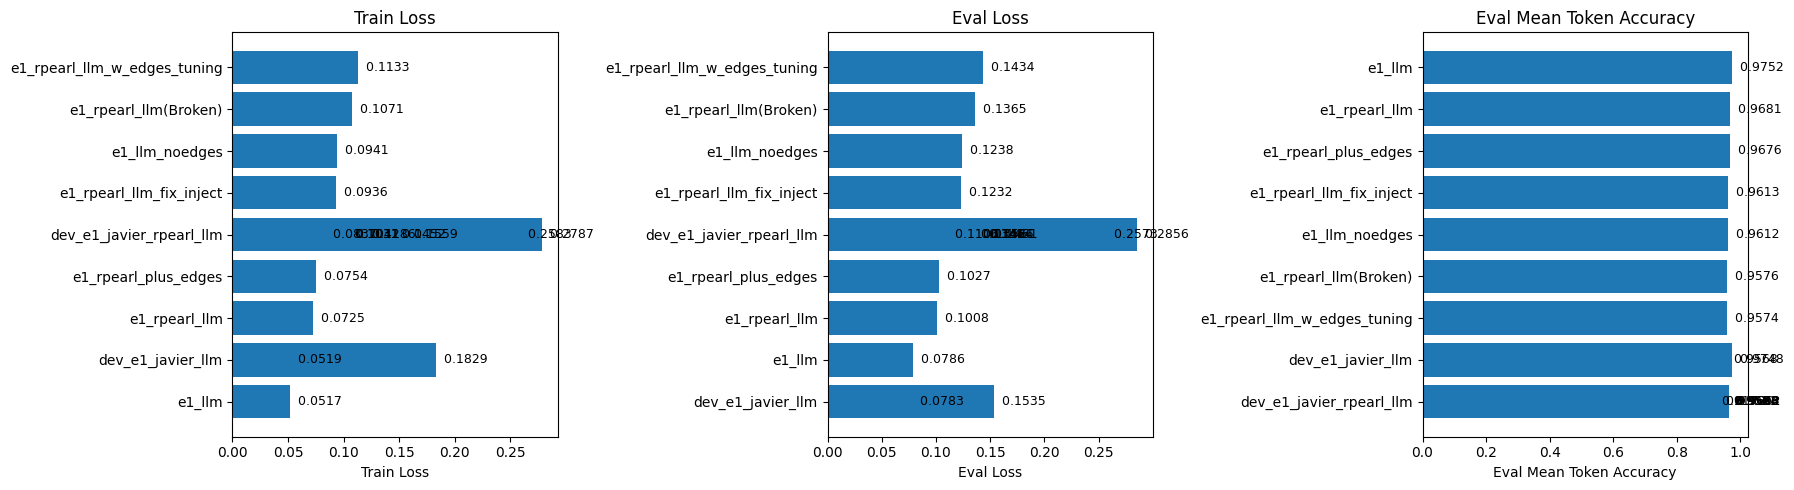

In [6]:
plot_metrics = [(TRAIN_LOSS, "Train Loss"), (EVAL_LOSS, "Eval Loss"), (EVAL_TOKEN_ACC, "Eval Mean Token Accuracy")]
plot_metrics = [(col, label) for col, label in plot_metrics if col is not None]

fig, axes = plt.subplots(1, len(plot_metrics), figsize=(6 * len(plot_metrics), 5))
if len(plot_metrics) == 1:
    axes = [axes]

for ax, (col, label) in zip(axes, plot_metrics):
    data = df[[ID_COL, col]].dropna(subset=[col]).sort_values(col)
    bars = ax.barh(data[ID_COL], data[col])
    ax.set_xlabel(label)
    ax.set_title(label)
    # Annotate bars
    for bar, val in zip(bars, data[col]):
        ax.text(bar.get_width(), bar.get_y() + bar.get_height() / 2,
                f"  {val:.4f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

## Per-run history plots (loss curves over training steps)

In [7]:
import wandb

api = wandb.Api()
runs = api.runs("alelab/GREP-PRISM", filters={"tags": "dev_e1_javier"})

histories = {}
for run in runs:
    hist = run.history(pandas=True)
    histories[run.name] = hist
    print(f"{run.name}: {len(hist)} steps")

dev_e1_javier_rpearl_llm: 14 steps
dev_e1_javier_rpearl_llm: 14 steps
dev_e1_javier_llm: 14 steps
e1_rpearl_llm(Broken): 136 steps
e1_llm: 136 steps
dev_e1_javier_rpearl_llm: 30 steps
dev_e1_javier_rpearl_llm: 136 steps
e1_llm_noedges: 136 steps
dev_e1_javier_rpearl_llm: 136 steps
e1_rpearl_llm_fix_inject: 136 steps
dev_e1_javier_llm: 136 steps
e1_rpearl_llm: 136 steps
e1_rpearl_plus_edges: 136 steps
dev_e1_javier_rpearl_llm: 0 steps
dev_e1_javier_rpearl_llm: 60 steps
dev_e1_javier_rpearl_llm: 136 steps
dev_e1_javier_rpearl_llm: 136 steps
e1_rpearl_llm_w_edges_tuning: 136 steps


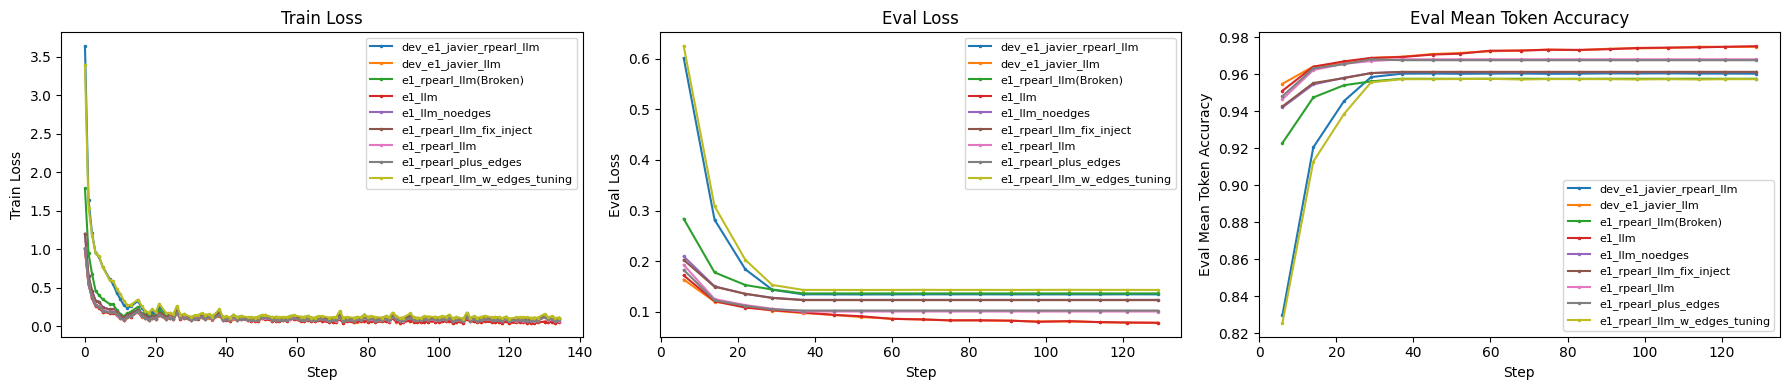

In [8]:
# Detect history column names from first run
sample_hist = next(iter(histories.values()))
hist_cols = sample_hist.columns.tolist()
h_train_loss = find_col(["train", "loss"], hist_cols) or find_col(["loss"], hist_cols)
h_eval_loss = find_col(["eval", "loss"], hist_cols)
h_eval_acc = find_col(["eval", "token", "acc"], hist_cols)

history_metrics = [
    (h_train_loss, "Train Loss"),
    (h_eval_loss, "Eval Loss"),
    (h_eval_acc, "Eval Mean Token Accuracy"),
]
history_metrics = [(c, l) for c, l in history_metrics if c is not None]

fig, axes = plt.subplots(1, len(history_metrics), figsize=(6 * len(history_metrics), 4))
if len(history_metrics) == 1:
    axes = [axes]

for ax, (col, label) in zip(axes, history_metrics):
    for run_name, hist in histories.items():
        series = hist[["_step", col]].dropna(subset=[col])
        ax.plot(series["_step"], series[col], label=run_name, marker=".", markersize=3)
    ax.set_xlabel("Step")
    ax.set_ylabel(label)
    ax.set_title(label)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## LaTeX Table — Eval Mean Token Accuracy

In [9]:
df.name.unique().tolist()

['dev_e1_javier_rpearl_llm',
 'dev_e1_javier_llm',
 'e1_rpearl_llm(Broken)',
 'e1_llm',
 'e1_llm_noedges',
 'e1_rpearl_llm_fix_inject',
 'e1_rpearl_llm',
 'e1_rpearl_plus_edges',
 'e1_rpearl_llm_w_edges_tuning']

In [10]:
RUN_TO_DISPLAY_NAME = {
    'dev_e1_javier_llm': 'LLM (Baseline)',
    'e1_llm_noedges': 'LLM (No Edges)',
    'e1_rpearl_llm_fix_inject': 'RPEARL-LLM (No Edges)',
    'e1_rpearl_plus_edges': 'RPEARL-LLM (+ Edges)',
    # outtakes
    #'dev_e1_javier_rpearl_llm': 'RPEARL-LLM',
    #'e1_rpearl_llm(Broken)': 'RPEARL-LLM (Broken)',
    #'e1_llm': 'LLM',
    #'e1_rpearl_llm': 'RPEARL-LLM',
    #'e1_rpearl_llm_w_edges_tuning': 'RPEARL-LLM (Tuning)',
}
df_to_report = df[df.name.isin(RUN_TO_DISPLAY_NAME.keys())].copy()
df_to_report["name"] = df_to_report["name"].map(RUN_TO_DISPLAY_NAME)

/tmp/ipykernel_4092869/1229458627.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_to_report.name = df.name.map(RUN_TO_DISPLAY_NAME)


In [11]:
df_to_report.name

2            LLM (Baseline)
7            LLM (No Edges)
9     RPEARL-LLM (No Edges)
10           LLM (Baseline)
12     RPEARL-LLM (+ Edges)
Name: name, dtype: object

In [18]:
if EVAL_TOKEN_ACC is not None:
    latex_df = df_to_report[[ID_COL, EVAL_TOKEN_ACC]].dropna(subset=[EVAL_TOKEN_ACC]).copy()
    latex_df[EVAL_TOKEN_ACC] = (latex_df[EVAL_TOKEN_ACC] * 100).round(2)
    latex_df = latex_df.rename(columns={ID_COL: "Run", EVAL_TOKEN_ACC: "Eval Mean Token Accuracy"})
    latex_df = latex_df.sort_values("Eval Mean Token Accuracy", ascending=False).reset_index(drop=True)
    
    # Compute diff relative to baseline
    baseline_acc = latex_df[latex_df["Run"] == "LLM (Baseline)"]["Eval Mean Token Accuracy"].iloc[0]
    latex_df["Diff vs Baseline"] = latex_df["Eval Mean Token Accuracy"] - baseline_acc
    
    #latex_df["Run"] = latex_df["Run"].str.replace("_", r"\_", regex=False)

    # Display as pandas
    display(latex_df)

    # Print copy-pasteable LaTeX
    print("\n% Copy-paste the LaTeX below:\n")
    latex_str = latex_df.to_latex(index=False, float_format="%.4f", caption="Eval Mean Token Accuracy for dev\\_e1\\_javier runs", label="tab:e1_token_acc")
    print(latex_str)
else:
    print("Could not find eval token accuracy column. Available metric columns:")
    for c in sorted(metric_cols):
        print(f"  {c}")


latex_str

,Run,Eval Mean Token Accuracy,Diff vs Baseline
0,LLM (Baseline),97.48,0.00
1,RPEARL-LLM (+ Edges),96.76,-0.72
2,RPEARL-LLM (No Edges),96.13,-1.35
3,LLM (No Edges),96.12,-1.36
4,LLM (Baseline),95.68,-1.80



% Copy-paste the LaTeX below:

\begin{table}
\caption{Eval Mean Token Accuracy for dev\_e1\_javier runs}
\label{tab:e1_token_acc}
\begin{tabular}{lrr}
\toprule
Run & Eval Mean Token Accuracy & Diff vs Baseline \\
\midrule
LLM (Baseline) & 97.4800 & 0.0000 \\
RPEARL-LLM (+ Edges) & 96.7600 & -0.7200 \\
RPEARL-LLM (No Edges) & 96.1300 & -1.3500 \\
LLM (No Edges) & 96.1200 & -1.3600 \\
LLM (Baseline) & 95.6800 & -1.8000 \\
\bottomrule
\end{tabular}
\end{table}



'\\begin{table}\n\\caption{Eval Mean Token Accuracy for dev\\_e1\\_javier runs}\n\\label{tab:e1_token_acc}\n\\begin{tabular}{lrr}\n\\toprule\nRun & Eval Mean Token Accuracy & Diff vs Baseline \\\\\n\\midrule\nLLM (Baseline) & 97.4800 & 0.0000 \\\\\nRPEARL-LLM (+ Edges) & 96.7600 & -0.7200 \\\\\nRPEARL-LLM (No Edges) & 96.1300 & -1.3500 \\\\\nLLM (No Edges) & 96.1200 & -1.3600 \\\\\nLLM (Baseline) & 95.6800 & -1.8000 \\\\\n\\bottomrule\n\\end{tabular}\n\\end{table}\n'